# Papermill + tmux test notebook

This notebook is designed to test what happens when a notebook is run with `papermill`.

It demonstrates:

- printed text output
- progress messages
- inline matplotlib images saved into the output notebook
- PNG files saved to disk
- metrics written incrementally to CSV/JSONL
- a rolling checkpoint file

Try running it from a terminal with:

```bash
mkdir -p runs logs
papermill papermill_tmux_test.ipynb runs/papermill_tmux_test_output.ipynb \
  --log-output \
  --request-save-on-cell-execute \
  --autosave-cell-every 10 \
  2>&1 | tee logs/papermill_tmux_test.log
```


In [1]:
# Parameters cell.
# Papermill can override these with -p, e.g.
# papermill papermill_tmux_test.ipynb runs/out.ipynb -p NUM_STEPS 30 -p SLEEP_SECONDS 0.5

RUN_NAME = "papermill_tmux_test"
NUM_STEPS = 20
SLEEP_SECONDS = 0.5
SAVE_EVERY = 5

# Set to a small integer like 7 to intentionally crash at that step.
# This lets you test what gets saved before failure.
FAIL_AT_STEP = None


In [2]:
from pathlib import Path
import json
import math
import random
import time
import datetime as dt

import pandas as pd
import matplotlib.pyplot as plt

base_dir = Path("runs") / RUN_NAME
fig_dir = base_dir / "figures"
ckpt_dir = base_dir / "checkpoints"
base_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir.mkdir(parents=True, exist_ok=True)

metrics_csv = base_dir / "metrics.csv"
metrics_jsonl = base_dir / "metrics.jsonl"
checkpoint_path = ckpt_dir / "latest_checkpoint.json"

print(f"Run name: {RUN_NAME}")
print(f"Output directory: {base_dir.resolve()}")
print(f"Started at: {dt.datetime.now().isoformat(timespec='seconds')}")


Run name: papermill_tmux_test
Output directory: /workspace/condition_df/runs/papermill_tmux_test
Started at: 2026-05-06T21:41:41


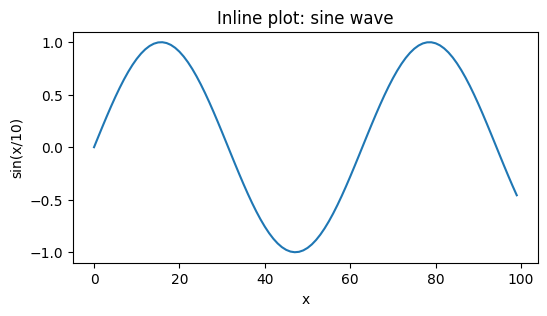

In [3]:
# A first inline plot.
# This image should appear inside the papermill output notebook.

xs = list(range(100))
ys = [math.sin(x / 10) for x in xs]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xs, ys)
ax.set_title("Inline plot: sine wave")
ax.set_xlabel("x")
ax.set_ylabel("sin(x/10)")
plt.show()


[step 001/20] loss=0.8990, accuracy_like=0.1070


[step 002/20] loss=0.8020, accuracy_like=0.2012


[step 003/20] loss=0.7082, accuracy_like=0.2944


[step 004/20] loss=0.6317, accuracy_like=0.3807


[step 005/20] loss=0.5430, accuracy_like=0.4674


Saved diagnostic figure: runs/papermill_tmux_test/figures/loss_step_0005.png


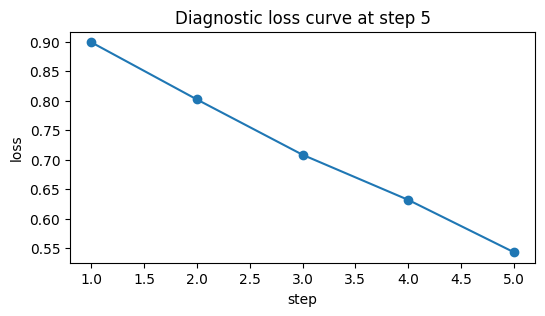

[step 006/20] loss=0.4874, accuracy_like=0.5200


[step 007/20] loss=0.4390, accuracy_like=0.5737


[step 008/20] loss=0.3829, accuracy_like=0.6268


[step 009/20] loss=0.3441, accuracy_like=0.6742


[step 010/20] loss=0.3079, accuracy_like=0.6935


Saved diagnostic figure: runs/papermill_tmux_test/figures/loss_step_0010.png


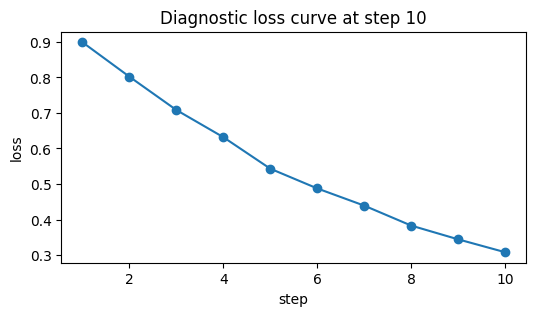

[step 011/20] loss=0.2622, accuracy_like=0.7381


[step 012/20] loss=0.2424, accuracy_like=0.7662


[step 013/20] loss=0.2031, accuracy_like=0.8107


[step 014/20] loss=0.1763, accuracy_like=0.8435


[step 015/20] loss=0.1594, accuracy_like=0.8604


Saved diagnostic figure: runs/papermill_tmux_test/figures/loss_step_0015.png


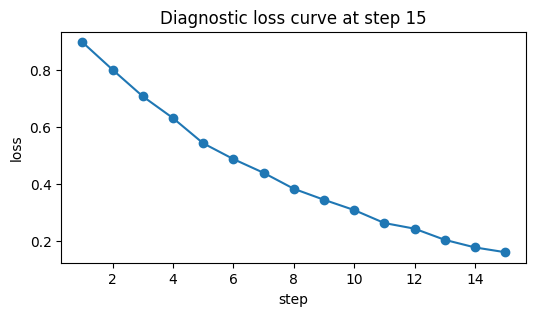

[step 016/20] loss=0.1617, accuracy_like=0.8464


[step 017/20] loss=0.1388, accuracy_like=0.8809


[step 018/20] loss=0.1326, accuracy_like=0.8740


[step 019/20] loss=0.0960, accuracy_like=0.9205


[step 020/20] loss=0.0870, accuracy_like=0.9233


Saved diagnostic figure: runs/papermill_tmux_test/figures/loss_step_0020.png


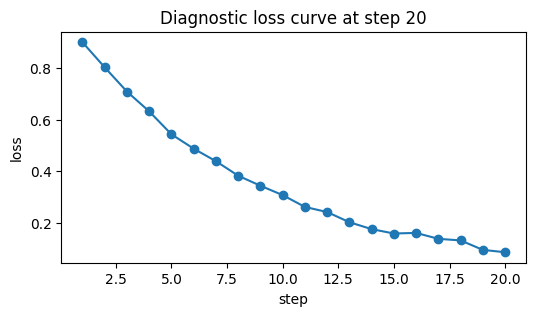

Finished loop.
Metrics CSV: runs/papermill_tmux_test/metrics.csv
Metrics JSONL: runs/papermill_tmux_test/metrics.jsonl
Latest checkpoint: runs/papermill_tmux_test/checkpoints/latest_checkpoint.json


In [4]:
# Long-ish loop simulating training.
# This writes metrics and checkpoint files incrementally.
# It also periodically saves diagnostic PNGs to disk and shows them inline.

rows = []

for step in range(1, NUM_STEPS + 1):
    # Simulated metric values
    loss = math.exp(-step / 8) + 0.03 * random.random()
    accuracy_like = 1 - loss + 0.02 * random.random()

    row = {
        "step": step,
        "loss": loss,
        "accuracy_like": accuracy_like,
        "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
    }
    rows.append(row)

    # Print output: with --log-output, this should appear in logs/papermill_tmux_test.log
    print(f"[step {step:03d}/{NUM_STEPS}] loss={loss:.4f}, accuracy_like={accuracy_like:.4f}", flush=True)

    # Append JSONL every step
    with metrics_jsonl.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")
        f.flush()

    # Overwrite CSV every step
    pd.DataFrame(rows).to_csv(metrics_csv, index=False)

    # Rolling checkpoint every step
    checkpoint = {
        "step": step,
        "latest_loss": loss,
        "latest_accuracy_like": accuracy_like,
        "run_name": RUN_NAME,
        "note": "This is a fake checkpoint, but it proves checkpointing works.",
    }
    checkpoint_path.write_text(json.dumps(checkpoint, indent=2), encoding="utf-8")

    # Periodic diagnostic image
    if step % SAVE_EVERY == 0 or step == NUM_STEPS:
        df = pd.DataFrame(rows)
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.plot(df["step"], df["loss"], marker="o")
        ax.set_title(f"Diagnostic loss curve at step {step}")
        ax.set_xlabel("step")
        ax.set_ylabel("loss")

        png_path = fig_dir / f"loss_step_{step:04d}.png"
        fig.savefig(png_path, dpi=160, bbox_inches="tight")
        print(f"Saved diagnostic figure: {png_path}", flush=True)
        plt.show()
        plt.close(fig)

    if FAIL_AT_STEP is not None and step == FAIL_AT_STEP:
        raise RuntimeError(f"Intentional failure at step {step}. Check saved metrics/checkpoint/images.")

    time.sleep(SLEEP_SECONDS)

print("Finished loop.")
print(f"Metrics CSV: {metrics_csv}")
print(f"Metrics JSONL: {metrics_jsonl}")
print(f"Latest checkpoint: {checkpoint_path}")


In [5]:
# Final summary table.
# This table should appear in the output notebook.

df = pd.read_csv(metrics_csv)
display(df.tail())

print("Final checkpoint contents:")
print(checkpoint_path.read_text())


,step,loss,accuracy_like,timestamp
15,16,0.161652,0.846378,2026-05-06T21:41:49
16,17,0.138816,0.880943,2026-05-06T21:41:50
17,18,0.132635,0.873994,2026-05-06T21:41:50
18,19,0.096001,0.920487,2026-05-06T21:41:51
19,20,0.087022,0.923266,2026-05-06T21:41:51


Final checkpoint contents:
{
  "step": 20,
  "latest_loss": 0.08702205249460775,
  "latest_accuracy_like": 0.92326603261614,
  "run_name": "papermill_tmux_test",
  "note": "This is a fake checkpoint, but it proves checkpointing works."
}


Saved final figure: runs/papermill_tmux_test/figures/final_loss_curve.png


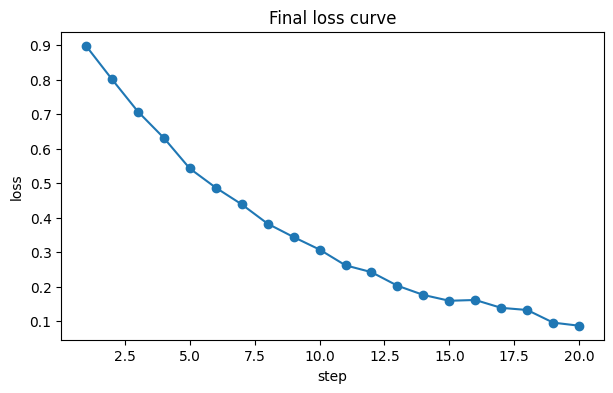

In [6]:
# Final plot.
# This should be embedded in the papermill output notebook and also saved as final_loss_curve.png.

df = pd.read_csv(metrics_csv)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["step"], df["loss"], marker="o")
ax.set_title("Final loss curve")
ax.set_xlabel("step")
ax.set_ylabel("loss")

final_png = fig_dir / "final_loss_curve.png"
fig.savefig(final_png, dpi=200, bbox_inches="tight")
print(f"Saved final figure: {final_png}")
plt.show()


## What to check after running

After papermill finishes, check:

```bash
ls -R runs/papermill_tmux_test
```

You should see:

```text
runs/papermill_tmux_test/
  metrics.csv
  metrics.jsonl
  checkpoints/latest_checkpoint.json
  figures/loss_step_0005.png
  figures/loss_step_0010.png
  figures/loss_step_0015.png
  figures/loss_step_0020.png
  figures/final_loss_curve.png
```

Also open:

```text
runs/papermill_tmux_test_output.ipynb
```

That output notebook should contain the printed outputs, tables, and inline plots.
